## Model for Hypothesis 2: varying transcript stability

varying transcript stability leads to differences in the degradation across transcripts.  
When a fixed mass of RNA is taken for the library preparation (~700 ng) every time, this can lead to an artificial increase of stable transcripts, as their realative abunance increases.  

This model simulates the abundance of maternal genes, assuming different degradation rates:
    - stable: k_deg = 0
    - unstable: k_deg = 0.2




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

1601
0
6399


c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\mgrho\AppData\Local\Temp\ipykernel_18388\3122549960.py:76: RuntimeWarning: Mean of empty slice.
  midly_stable_mean = T_maternal[:, midly_stable].mean(axis=1)
c:\Users\mgrho\anaconda3\envs\thesis3\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


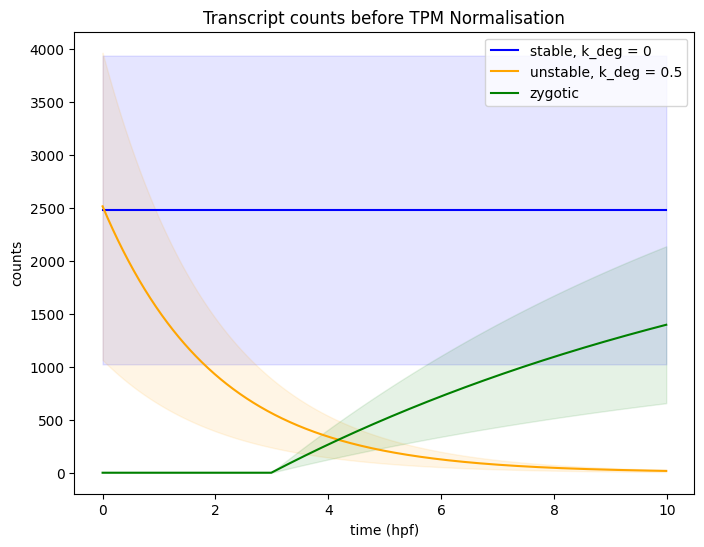

In [2]:
t_end = 10
dt = 0.01
time = np.arange(0, t_end, dt)

n_maternal = 8000
n_zygotic = 2000
rng = np.random.default_rng(1)


# -------------------------------
# 1. MATERNAL TRANSCRIPTS ONLY
# -------------------------------

# initial maternal counts
T0_maternal = rng.integers(low=10, high=5000, size=n_maternal)

# degradation rates for maternal mRNAs
k_deg_maternal = np.random.choice(
    [0.0, 0.5], 
    size=n_maternal, 
    p=[0.2, 0.8]
)

# initialize trace
T_maternal = np.zeros((len(time), n_maternal))
T_maternal[0, :] = T0_maternal

# simulate maternal decay
for i in range(1, len(time)):
    T_prev = T_maternal[i-1, :]
    T_maternal[i, :] = T_prev * np.exp(-k_deg_maternal * dt)


# -------------------------------
# 2. ZYGOTIC TRANSCRIPTS ONLY
# -------------------------------

# zygotic transcripts start at ZERO
T_zyg = np.zeros((len(time), n_zygotic))

# transcription rates
k_prod_zyg = rng.choice([100, 200, 300, 500], size=n_zygotic,)
# degradation rates for zygotic mRNAs
k_deg_zyg = rng.choice([0.1], size=n_zygotic,)

# simulate ZGA onset at 3 hpf
for i in range(1, len(time)):

    T_prev = T_zyg[i-1, :]

    if time[i] < 3:
        # no transcription yet
        dT = -k_deg_zyg * T_prev * dt
    else:
        # transcription + degradation
        dT = (k_prod_zyg - k_deg_zyg * T_prev) * dt

    T_zyg[i, :] = T_prev + dT

T_total = np.hstack([T_maternal, T_zyg])


# --- plot resutls ---
stable = (k_deg_maternal == 0.0)
print(np.sum(stable))
midly_stable = (k_deg_maternal == 0.1) 
print(np.sum(midly_stable))
unstable = (k_deg_maternal == 0.5)
print(np.sum(unstable))

fig, ax = plt.subplots(figsize=(8, 6))

stable_mean = T_maternal[:, stable].mean(axis=1)
stable_std = T_maternal[:, stable].std(axis=1)
midly_stable_std = T_maternal[:, midly_stable].std(axis=1)
midly_stable_mean = T_maternal[:, midly_stable].mean(axis=1)
unstable_std = T_maternal[:, unstable].std(axis=1)
unstable_mean = T_maternal[:, unstable].mean(axis=1)

zygotic_mean = T_zyg[:,].mean(axis=1)
zygotic_std = T_zyg[:, ].std(axis=1)

plt.plot(time, stable_mean, label="stable, k_deg = 0", color="blue")
plt.fill_between(time, stable_mean - stable_std, stable_mean + stable_std,alpha=0.1, color="blue")
plt.plot(time, unstable_mean, label="unstable, k_deg = 0.5", color="orange")
plt.fill_between(time, unstable_mean - unstable_std, unstable_mean + unstable_std,alpha=0.1, color="orange")

plt.plot(time, zygotic_mean, label="zygotic", color="green")
plt.fill_between(time, zygotic_mean - zygotic_std, zygotic_mean + zygotic_std,alpha=0.1, color="green")
#plt.plot(time, midly_stable_mean, label="midly stable, k_deg = 0.1", color="green")
#plt.fill_between(time, midly_stable_mean - midly_stable_std, midly_stable_mean + midly_stable_std,alpha=0.1, color="green")

ax.set_xlabel("time (hpf)")
ax.set_ylabel("counts")
ax.set_title("Transcript counts before TPM Normalisation")
ax.legend(loc="upper right")
plt.show()

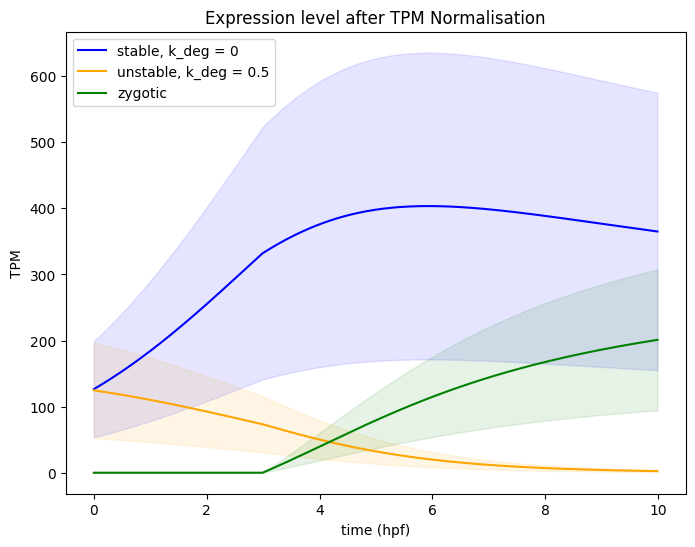

In [140]:
# TPM normalization

L_maternal = rng.uniform(low=1, high=3, size=n_maternal)
L_zyg      = rng.uniform(low=1, high=3, size=n_zygotic)
L_transcript_kb = np.hstack([L_maternal, L_zyg])
L_fragment_kb = np.full(n_maternal + n_zygotic, 0.15) ## fragment length in kb

def TPM(transcript_counts, L_transcript_kb, L_frag_kb):
    """
    Reads to TPM
    S_depth = total sequencing depth
    """
    reads =  transcript_counts * (L_transcript_kb / L_frag_kb)
    RPK = reads / L_transcript_kb
    S_depth = np.sum(RPK, axis=1, keepdims=True)
    return (RPK / S_depth) * 1e6

TPM_values  = TPM(T_total, L_transcript_kb, L_fragment_kb)


# --- plot resutls ---
fig, ax = plt.subplots(figsize=(8, 6))

# Combined TPM order: maternal first, then zygotic
stable_mask = np.hstack([k_deg_maternal == 0.0, np.zeros(n_zygotic, dtype=bool)])
unstable_mask = np.hstack([k_deg_maternal == 0.5, np.zeros(n_zygotic, dtype=bool)])
zygotic_mask = np.hstack([np.zeros(n_maternal, dtype=bool), np.ones(n_zygotic, dtype=bool)])

sum(stable_mask)


stable_mean = TPM_values[:, stable_mask].mean(axis=1)
stable_std = TPM_values[:, stable_mask].std(axis=1)
unstable_std = TPM_values[:, unstable_mask].std(axis=1)
unstable_mean = TPM_values[:, unstable_mask].mean(axis=1)

zyg_mean = TPM_values[:, zygotic_mask].mean(axis=1)
zyg_std  = TPM_values[:, zygotic_mask].std(axis=1)

plt.plot(time, stable_mean, label="stable, k_deg = 0", color="blue")
plt.fill_between(time, stable_mean - stable_std, stable_mean + stable_std,alpha=0.1, color="blue")
plt.plot(time, unstable_mean, label="unstable, k_deg = 0.5", color="orange")
plt.fill_between(time, unstable_mean - unstable_std, unstable_mean + unstable_std,alpha=0.1, color="orange")

ax.plot(time, zyg_mean, label="zygotic", color="green")
ax.fill_between(time, zyg_mean - zyg_std, zyg_mean + zyg_std, alpha=0.1, color="green")

ax.set_xlabel("time (hpf)")
ax.set_ylabel("TPM")
ax.set_title("Expression level after TPM Normalisation")
ax.legend()
plt.show()

#### With normlisation to mass

need to differentiate between total RNA amount in sample and konstant RNA amount for library prep

In [12]:
def true_expression(t, M0, k, t_zga=3, s= 0.5, mode="exp"):
    '''maternal genes only
    see Tadros & Lipshitz 2009; different degradation profiles
    a) before ZGA (t_zga=3)
    b) during ZGA
    c) after ZGA
    '''
    if mode == "exp":
        return np.where(t < t_zga, 
                    M0, 
                    M0 * np.exp(-k * (t - t_zga)))
        
    if mode == "sig":
        return M0 / (1 + np.exp((t - t_zga) / s))